NumPy, Pandas & Matplotlib Integration

        capacity_mw  commissioning_year
count  34936.000000        17447.000000
mean     163.355148         1997.414823
std      489.636072           23.397835
min        1.000000         1896.000000
25%        4.900000         1988.000000
50%       16.745000         2007.000000
75%       75.344250         2014.000000
max    22500.000000         2020.000000
country_long
United States of America    9833
China                       4235
United Kingdom              2751
Brazil                      2360
France                      2155
India                       1589
Germany                     1309
Canada                      1159
Spain                        829
Russia                       545
Name: count, dtype: int64
primary_fuel
Solar             10665
Hydro              7156
Wind               5344
Gas                3998
Coal               2330
Oil                2320
Biomass            1430
Waste              1068
Nuclear             195
Geothermal          189
Storage           

<Figure size 1400x600 with 0 Axes>

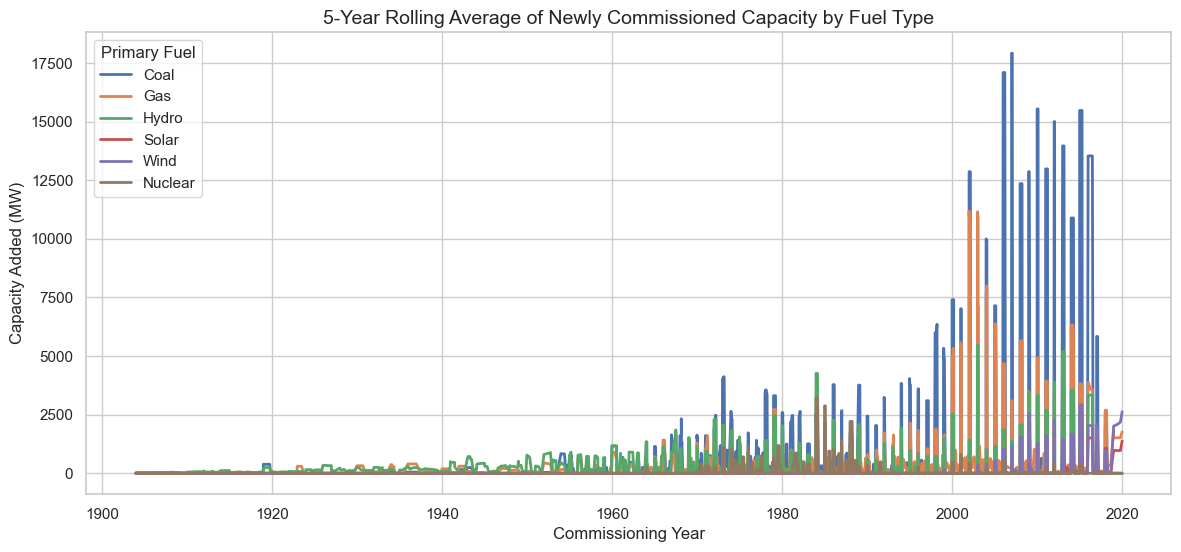

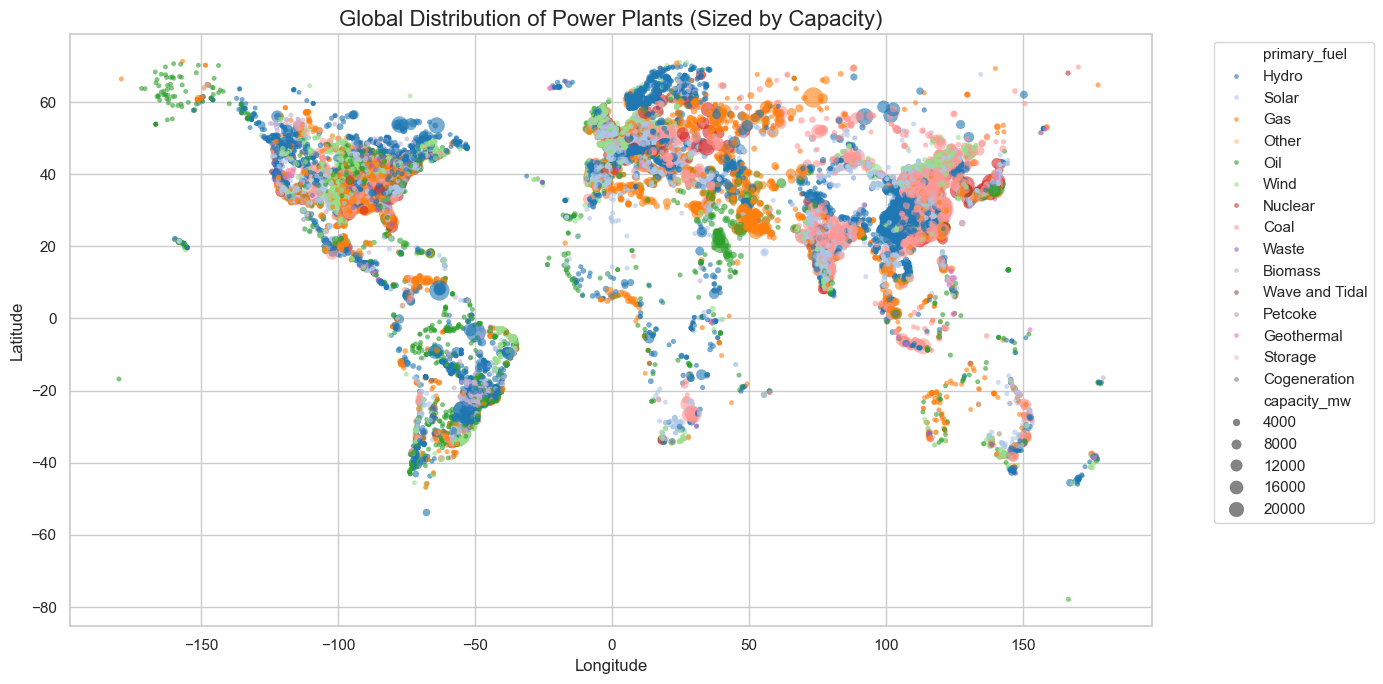

Correlation Matrix:
 [[ 1.    -0.013  0.152]
 [-0.013  1.    -0.068]
 [ 0.152 -0.068  1.   ]]
Eigenvalues:
 [1.171 0.838 0.99 ]
Eigenvectors:
 [[-0.64   0.651  0.408]
 [ 0.327 -0.25   0.912]
 [-0.696 -0.716  0.053]]
plant_scale
Standard Plant    31763
Large Plant        1604
Mega Plant         1569
Name: count, dtype: int64


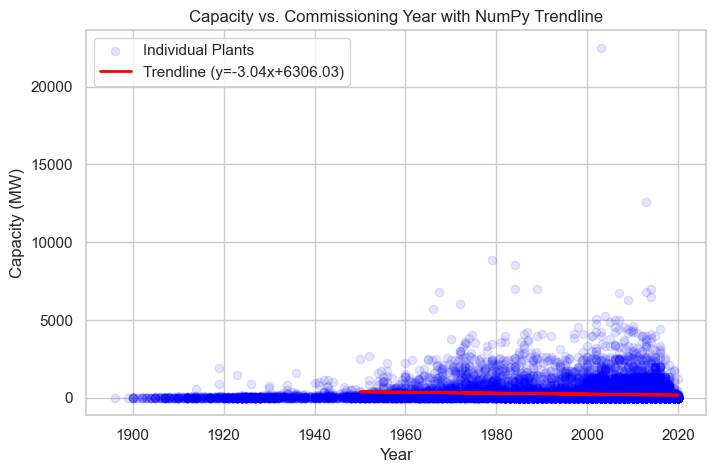

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('global_power_plant_database.csv', low_memory=False)

df['commissioning_year'] = pd.to_numeric(df['commissioning_year'], errors='coerce')
df['primary_fuel'] = df['primary_fuel'].fillna('Unknown')
df['capacity_mw'] = pd.to_numeric(df['capacity_mw'], errors='coerce')

num_stats = df[['capacity_mw', 'commissioning_year']].describe()
print(num_stats)

top_countries = df['country_long'].value_counts().head(10)
print(top_countries)

fuel_dist = df['primary_fuel'].value_counts()
print(fuel_dist)

coal_capacity = df[df['primary_fuel'] == 'Coal']['capacity_mw'].dropna().values
solar_capacity = df[df['primary_fuel'] == 'Solar']['capacity_mw'].dropna().values

print(f"Mean Coal Capacity: {np.mean(coal_capacity):.2f} MW")
print(f"Mean Solar Capacity: {np.mean(solar_capacity):.2f} MW")

t_stat, p_value = stats.ttest_ind(coal_capacity, solar_capacity, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4e}")

valid_years_df = df[(df['commissioning_year'] > 1900) & (df['commissioning_year'] <= 2020)].copy()

yearly_capacity = valid_years_df.groupby('commissioning_year')['capacity_mw'].sum()
fuel_trends = valid_years_df.groupby(['commissioning_year', 'primary_fuel'])['capacity_mw'].sum().unstack().fillna(0)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 6))
major_fuels = ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind', 'Nuclear']
fuel_trends[major_fuels].rolling(window=5).mean().plot(figsize=(14,6), linewidth=2)
plt.title('5-Year Rolling Average of Newly Commissioned Capacity by Fuel Type', fontsize=14)
plt.xlabel('Commissioning Year')
plt.ylabel('Capacity Added (MW)')
plt.legend(title='Primary Fuel')
plt.show()

plt.figure(figsize=(14, 7))
map_df = df.dropna(subset=['latitude', 'longitude'])

sns.scatterplot(
    data=map_df, 
    x='longitude', 
    y='latitude', 
    hue='primary_fuel',
    size='capacity_mw',
    sizes=(10, 500),
    alpha=0.6,
    palette='tab20',
    edgecolor=None
)
plt.title('Global Distribution of Power Plants (Sized by Capacity)', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=0.5)
plt.tight_layout()
plt.show()

features = ['capacity_mw', 'latitude', 'longitude']
data_matrix = df[features].dropna().values
data_standardized = (data_matrix - np.mean(data_matrix, axis=0)) / np.std(data_matrix, axis=0)

corr_matrix = np.corrcoef(data_standardized, rowvar=False)
print("Correlation Matrix:\n", np.round(corr_matrix, 3))

eigenvalues, eigenvectors = np.linalg.eig(corr_matrix)
print("Eigenvalues:\n", np.round(eigenvalues, 3))
print("Eigenvectors:\n", np.round(eigenvectors, 3))

df['plant_scale'] = np.where(df['capacity_mw'] > 1000, 'Mega Plant',
                     np.where(df['capacity_mw'] > 500, 'Large Plant', 'Standard Plant'))

print(df['plant_scale'].value_counts())

plt.figure(figsize=(8, 5))
x_data = df['commissioning_year'].dropna().values
y_data = df.loc[df['commissioning_year'].notna(), 'capacity_mw'].values

plt.scatter(x_data, y_data, alpha=0.1, color='blue', label='Individual Plants')

valid_idx = (x_data > 1950) 
x_fit = x_data[valid_idx]
y_fit = y_data[valid_idx]

m, b = np.polyfit(x_fit, y_fit, 1)
plt.plot(x_fit, m*x_fit + b, color='red', linewidth=2, label=f'Trendline (y={m:.2f}x+{b:.2f})')

plt.title('Capacity vs. Commissioning Year with NumPy Trendline')
plt.xlabel('Year')
plt.ylabel('Capacity (MW)')
plt.legend()
plt.show()